# Alpha vs Horizon

Sweeps `label_k` (smoothed-mid look-ahead/look-back window) and shows how the calibrated alpha threshold,
class balance, and the full |trend_ratio| distribution change with horizon.

Mid prices are loaded directly from the raw Binance snapshot files — no feature cache required.

In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# resolve src/ relative to notebook location
ROOT = Path("__file__").resolve().parent.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

In [ ]:
from crypto.labels import assign_labels, calibrate_alpha, compute_trend_series

In [2]:
# ── parameters ────────────────────────────────────────────────────────────────
SYMBOL = "BTCUSDT"  # change to any symbol in data/binance
DATA_DIR = ROOT / "data" / "binance"
TRAIN_FRAC = 0.70  # must match model configs

HORIZONS = [1, 2, 5, 10, 20, 50, 100]  # label_k values to sweep
DIST_KS = [5, 10, 20, 50]  # subset shown in distribution plot

In [3]:
def load_mid(data_dir: Path, symbol: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (mid_prices, timestamps_µs) concatenated across all available days."""
    pat = re.compile(
        rf"binance_book_snapshot_25_(\d{{4}}-\d{{2}}-\d{{2}})_{re.escape(symbol)}\.csv\.gz$"
    )
    snap_files = sorted(f for f in data_dir.iterdir() if pat.match(f.name))
    if not snap_files:
        raise FileNotFoundError(f"No snapshot files for {symbol} in {data_dir}")

    mids, tss = [], []
    for f in snap_files:
        df = pd.read_csv(
            f, usecols=["timestamp", "bids[0].price", "asks[0].price"], dtype=np.float64
        )
        df.dropna(inplace=True)
        if df.empty:
            continue
        mid = (df["bids[0].price"].values + df["asks[0].price"].values) / 2.0
        mids.append(mid)
        tss.append(df["timestamp"].values.astype(np.int64))
        print(f"  {pat.match(f.name).group(1)}  {len(df):>7,} rows")

    return np.concatenate(mids), np.concatenate(tss)


print(f"Loading mid prices for {SYMBOL} …")
mid, ts = load_mid(DATA_DIR, SYMBOL)
N = len(mid)
train_end = int(N * TRAIN_FRAC)
print(f"\nTotal snapshots : {N:,}")
print(f"Train snapshots : {train_end:,}  ({TRAIN_FRAC:.0%})")

Loading mid prices for BTCUSDT …
  2026-06-09  736,833 rows
  2026-06-10  762,131 rows
  2026-06-11  719,652 rows
  2026-06-12  677,325 rows
  2026-06-13  512,620 rows
  2026-06-14  545,534 rows
  2026-06-15  684,934 rows
  2026-06-16  678,371 rows
  2026-06-17  706,616 rows

Total snapshots : 6,024,016
Train snapshots : 4,216,811  (70%)


In [4]:
# ── sweep horizons ────────────────────────────────────────────────────────────
results = []
trend_series = {}  # k → np.ndarray for distribution plots

for k in HORIZONS:
    tr = compute_trend_series(mid, k)
    alpha = calibrate_alpha(tr[:train_end])
    labels = assign_labels(tr, alpha)

    valid = labels >= 0
    n_valid = valid.sum()
    counts = np.bincount(labels[valid], minlength=3)
    bal = counts / n_valid

    # also compute what alpha would perfectly balance classes (50th pct of |tr|)
    alpha_50 = float(
        np.percentile(np.abs(tr[:train_end][np.isfinite(tr[:train_end])]), 50.0)
    )

    results.append(
        {
            "k": k,
            "alpha": alpha,
            "alpha_50pct": alpha_50,
            "down_frac": bal[0],
            "stat_frac": bal[1],
            "up_frac": bal[2],
            "n_valid": n_valid,
        }
    )
    trend_series[k] = tr
    print(
        f"k={k:>3}  alpha={alpha:.6f}  "
        f"down={bal[0]:.1%}  stat={bal[1]:.1%}  up={bal[2]:.1%}  "
        f"valid={n_valid:,}"
    )

df_res = pd.DataFrame(results).set_index("k")
df_res

k=  1  alpha=0.000000  down=2.7%  stat=94.6%  up=2.7%  valid=6,024,014
k=  2  alpha=0.000000  down=6.2%  stat=87.7%  up=6.2%  valid=6,024,012
k=  5  alpha=0.000000  down=13.6%  stat=72.7%  up=13.7%  valid=6,024,006
k= 10  alpha=0.000000  down=21.7%  stat=56.2%  up=22.1%  valid=6,023,996
k= 20  alpha=0.000000  down=31.2%  stat=36.9%  up=31.9%  valid=6,023,976
k= 50  alpha=0.000025  down=32.9%  stat=33.9%  up=33.2%  valid=6,023,916
k=100  alpha=0.000054  down=33.1%  stat=33.5%  up=33.3%  valid=6,023,816


,alpha,alpha_50pct,down_frac,stat_frac,up_frac,n_valid
k,,,,,,
1,0.000000,0.000000,0.027447,0.945772,0.026781,6024014
2,0.000000,0.000000,0.061945,0.876544,0.061510,6024012
5,0.000000,0.000000,0.135858,0.727256,0.136886,6024006
10,0.000000,0.000000,0.217255,0.562148,0.220597,6023996
20,0.000000,0.000016,0.312387,0.368673,0.318940,6023976
50,0.000025,0.000056,0.328950,0.339104,0.331946,6023916
100,0.000054,0.000097,0.331456,0.335246,0.333298,6023816


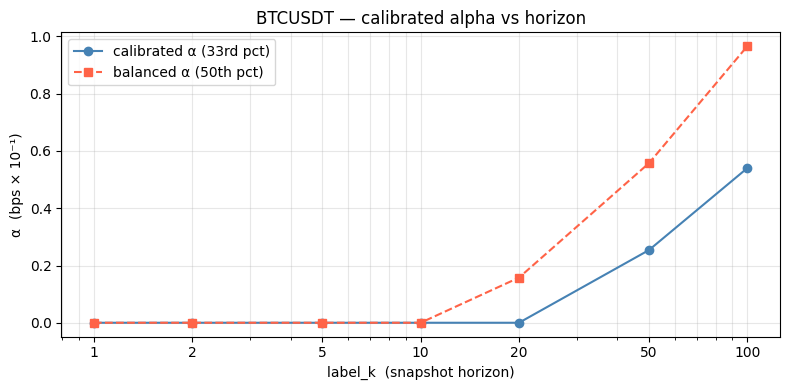

In [5]:
# ── figure 1: alpha vs horizon ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    df_res.index,
    df_res["alpha"] * 1e4,
    "o-",
    color="steelblue",
    label="calibrated α (33rd pct)",
)
ax.plot(
    df_res.index,
    df_res["alpha_50pct"] * 1e4,
    "s--",
    color="tomato",
    label="balanced α (50th pct)",
)

ax.set_xlabel("label_k  (snapshot horizon)")
ax.set_ylabel("α  (bps × 10⁻¹)")
ax.set_title(f"{SYMBOL} — calibrated alpha vs horizon")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(HORIZONS)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

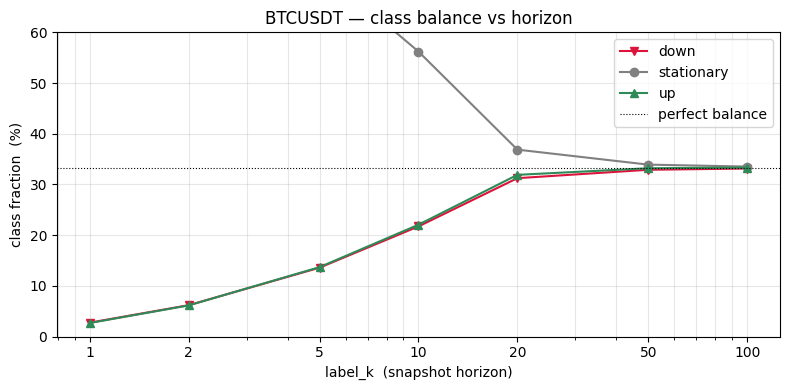

In [6]:
# ── figure 2: class balance vs horizon ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_res.index, df_res["down_frac"] * 100, "v-", color="crimson", label="down")
ax.plot(df_res.index, df_res["stat_frac"] * 100, "o-", color="gray", label="stationary")
ax.plot(df_res.index, df_res["up_frac"] * 100, "^-", color="seagreen", label="up")
ax.axhline(
    100 / 3, color="black", linestyle=":", linewidth=0.8, label="perfect balance"
)

ax.set_xlabel("label_k  (snapshot horizon)")
ax.set_ylabel("class fraction  (%)")
ax.set_title(f"{SYMBOL} — class balance vs horizon")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(HORIZONS)
ax.set_ylim(0, 60)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

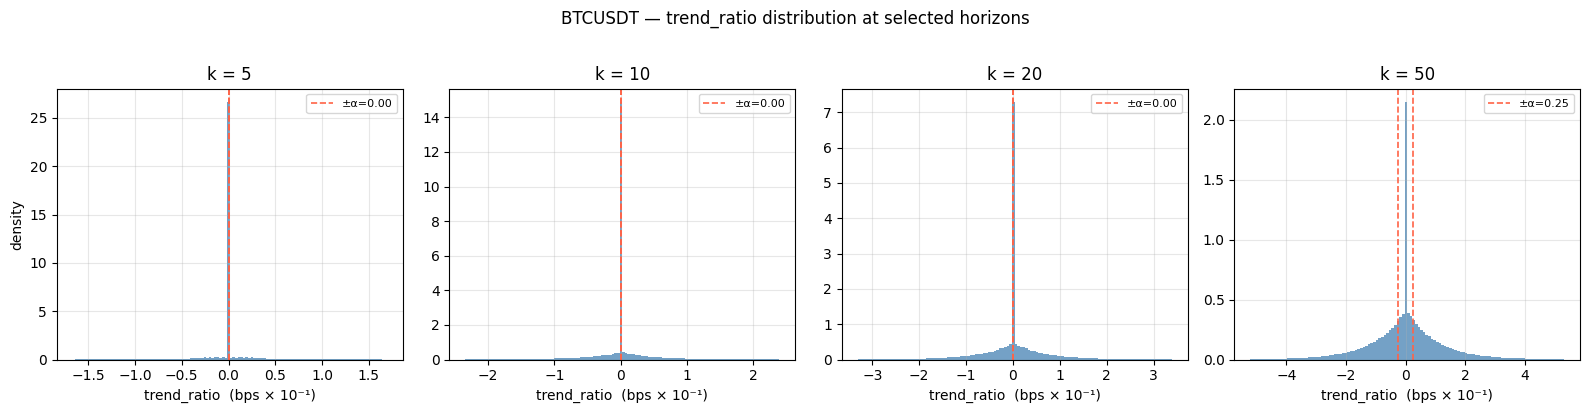

In [7]:
# ── figure 3: |trend_ratio| distributions at selected horizons ───────────────
plot_ks = [k for k in DIST_KS if k in trend_series]
n_panels = len(plot_ks)
fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
if n_panels == 1:
    axes = [axes]

for ax, k in zip(axes, plot_ks):
    tr = trend_series[k]
    valid_tr = tr[np.isfinite(tr)]
    alpha_k = df_res.loc[k, "alpha"]

    # clip tails for readability
    p1, p99 = np.percentile(valid_tr, [0.5, 99.5])
    clipped = valid_tr[(valid_tr >= p1) & (valid_tr <= p99)]

    ax.hist(clipped * 1e4, bins=120, color="steelblue", alpha=0.75, density=True)
    for sign, color in [(1, "tomato"), (-1, "tomato")]:
        ax.axvline(
            sign * alpha_k * 1e4,
            color=color,
            linestyle="--",
            linewidth=1.2,
            label=f"±α={alpha_k * 1e4:.2f}" if sign == 1 else None,
        )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("trend_ratio  (bps × 10⁻¹)")
    ax.set_ylabel("density" if ax is axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{SYMBOL} — trend_ratio distribution at selected horizons", y=1.02)
plt.tight_layout()
plt.show()

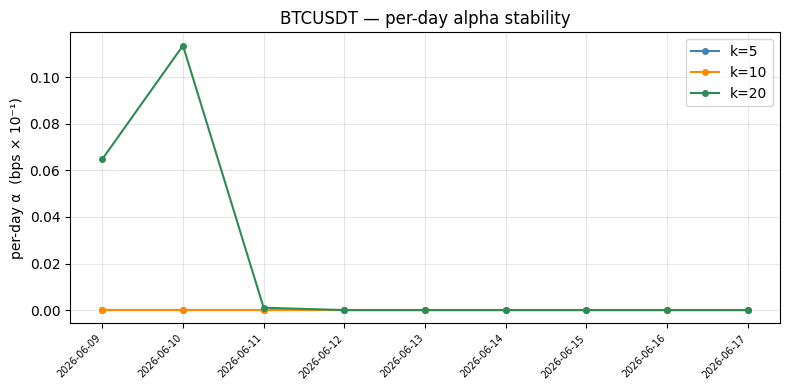

In [8]:
# ── figure 4: per-day alpha stability ────────────────────────────────────────
# Recompute alpha on a rolling calendar-day basis to see how stable it is
pat = re.compile(
    rf"binance_book_snapshot_25_(\d{{4}}-\d{{2}}-\d{{2}})_{re.escape(SYMBOL)}\.csv\.gz$"
)
snap_files = sorted(f for f in DATA_DIR.iterdir() if pat.match(f.name))

K_FOCUS = [k for k in [5, 10, 20] if k in trend_series]  # horizons to compare
day_alphas = {k: [] for k in K_FOCUS}
dates = []

for f in snap_files:
    date = pat.match(f.name).group(1)
    df = pd.read_csv(f, usecols=["bids[0].price", "asks[0].price"], dtype=np.float64)
    df.dropna(inplace=True)
    if len(df) < 200:
        continue
    mid_day = (df["bids[0].price"].values + df["asks[0].price"].values) / 2.0
    dates.append(date)
    for k in K_FOCUS:
        if len(mid_day) <= 2 * k:
            day_alphas[k].append(np.nan)
        else:
            tr_day = compute_trend_series(mid_day, k)
            day_alphas[k].append(calibrate_alpha(tr_day))

fig, ax = plt.subplots(figsize=(max(8, len(dates) * 0.5), 4))
x = range(len(dates))
colors = ["steelblue", "darkorange", "seagreen"]
for (k, vals), color in zip(day_alphas.items(), colors):
    ax.plot(x, np.array(vals) * 1e4, "o-", label=f"k={k}", color=color, markersize=4)

ax.set_xticks(list(x))
ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("per-day α  (bps × 10⁻¹)")
ax.set_title(f"{SYMBOL} — per-day alpha stability")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── summary table ─────────────────────────────────────────────────────────────
summary = df_res[["alpha", "alpha_50pct", "down_frac", "stat_frac", "up_frac"]].copy()
summary["alpha_bps"] = (summary.pop("alpha") * 1e4).round(4)
summary["alpha_50_bps"] = (summary.pop("alpha_50pct") * 1e4).round(4)
summary["down_%"] = (summary.pop("down_frac") * 100).round(1)
summary["stat_%"] = (summary.pop("stat_frac") * 100).round(1)
summary["up_%"] = (summary.pop("up_frac") * 100).round(1)
summary.index.name = "label_k"
summary

,alpha_bps,alpha_50_bps,down_%,stat_%,up_%
label_k,,,,,
1,0.0000,0.0000,2.7,94.6,2.7
2,0.0000,0.0000,6.2,87.7,6.2
5,0.0000,0.0000,13.6,72.7,13.7
10,0.0000,0.0000,21.7,56.2,22.1
20,0.0000,0.1576,31.2,36.9,31.9
50,0.2540,0.5576,32.9,33.9,33.2
100,0.5403,0.9662,33.1,33.5,33.3
